<a href="https://colab.research.google.com/github/KrithikChidM/PrmlLab/blob/main/Lab3/Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Dataset: /content/drive/MyDrive/Krithik SNU/HAM/noisy_7.txt
Total samples: 10000
Training samples: 6000
Testing samples: 2000
Validation samples: 2000

Polynomial Regression Experiments
----------------------------------
Degree   Train MSE       Test MSE        Validation MSE 
1        1688.784122     1855.618158     1829.413875    
2        1651.782542     1790.444441     1759.815895    
3        1405.779848     1553.557649     1541.904475    
4        1316.866235     1544.176017     1522.671259    
5        999.525587      1095.333814     1103.085850    
6        689.026175      754.463740      789.834876     
7        689.024402      754.325075      789.597221     
8        575.114135      591.910008      613.537625     
9        360.748764      369.464710      364.829772     
10       360.732081      369.690243      364.884098     

Best Polynomial Model
---------------------
Selected Degree: 9

Weights:
w0 = -19.5909435209
w1 = 29.7668242995
w2 = 944.5844843817
w3 = 1592.469654370

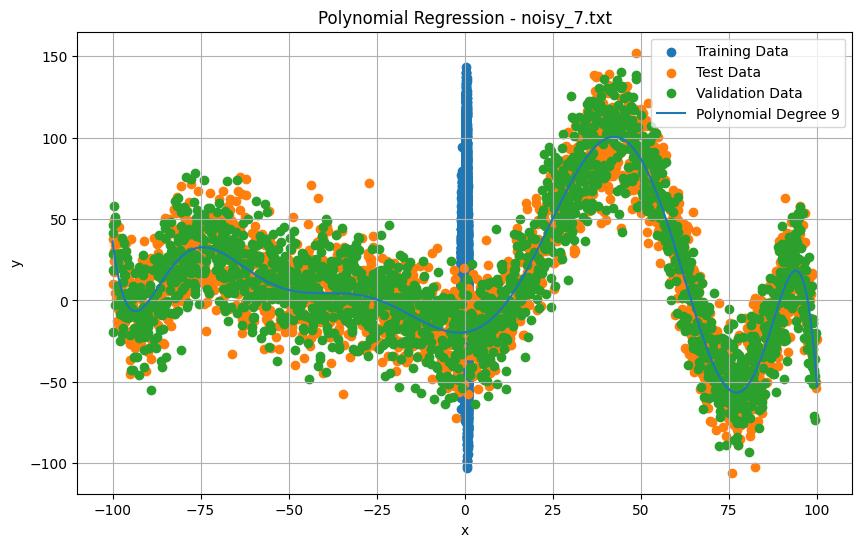

In [ ]:

import math
import matplotlib.pyplot as plt

filename = "/content/drive/MyDrive/Krithik SNU/HAM/noisy_7.txt"


def read_data(filename):
    data = []

    with open(filename, "r") as file:
        for line in file:
            line = line.strip()

            if line == "":
                continue

            values = line.split()

            if len(values) >= 2:
                x = float(values[0])
                y = float(values[1])
                data.append((x, y))

    return data


def shuffle_data(data, seed=42):
    data = data[:]

    for i in range(len(data) - 1, 0, -1):
        seed = (seed * 1103515245 + 12345) % 2147483648
        j = seed % (i + 1)

        data[i], data[j] = data[j], data[i]

    return data


def split_data(data):
    data = shuffle_data(data)

    n = len(data)

    train_end = int(0.60 * n)
    test_end = int(0.80 * n)

    train = data[:train_end]
    test = data[train_end:test_end]
    validation = data[test_end:]

    return train, test, validation


def normalize_data(data):
    x_values = [x for x, y in data]

    minimum = min(x_values)
    maximum = max(x_values)

    result = []

    for x, y in data:
        if maximum == minimum:
            new_x = 0.0
        else:
            new_x = 2.0 * (x - minimum) / (maximum - minimum) - 1.0

        result.append((new_x, y))

    return result, minimum, maximum


def normalize_x(x, minimum, maximum):
    if maximum == minimum:
        return 0.0

    return 2.0 * (x - minimum) / (maximum - minimum) - 1.0


def create_design_matrix(data, degree):
    X = []

    for x, y in data:
        row = []

        value = 1.0

        for j in range(degree + 1):
            row.append(value)
            value *= x

        X.append(row)

    return X


def transpose(A):
    rows = len(A)
    cols = len(A[0])

    result = []

    for j in range(cols):
        row = []

        for i in range(rows):
            row.append(A[i][j])

        result.append(row)

    return result


def matrix_multiply(A, B):
    rows_A = len(A)
    cols_A = len(A[0])
    cols_B = len(B[0])

    result = [
        [0.0 for j in range(cols_B)]
        for i in range(rows_A)
    ]

    for i in range(rows_A):
        for j in range(cols_B):
            total = 0.0

            for k in range(cols_A):
                total += A[i][k] * B[k][j]

            result[i][j] = total

    return result


def identity_matrix(n):
    I = []

    for i in range(n):
        row = []

        for j in range(n):
            if i == j:
                row.append(1.0)
            else:
                row.append(0.0)

        I.append(row)

    return I


def inverse_matrix(A):
    n = len(A)

    augmented = []

    I = identity_matrix(n)

    for i in range(n):
        augmented.append(A[i][:] + I[i][:])

    for i in range(n):

        pivot_row = i

        for j in range(i + 1, n):
            if abs(augmented[j][i]) > abs(augmented[pivot_row][i]):
                pivot_row = j

        if abs(augmented[pivot_row][i]) < 1e-12:
            return None

        augmented[i], augmented[pivot_row] = (
            augmented[pivot_row],
            augmented[i]
        )

        pivot = augmented[i][i]

        for j in range(2 * n):
            augmented[i][j] /= pivot

        for j in range(n):

            if j != i:

                factor = augmented[j][i]

                for k in range(2 * n):
                    augmented[j][k] -= factor * augmented[i][k]

    inverse = []

    for i in range(n):
        inverse.append(augmented[i][n:])

    return inverse


def pseudo_inverse(X):
    XT = transpose(X)

    XTX = matrix_multiply(XT, X)

    inverse = inverse_matrix(XTX)

    if inverse is None:
        return None

    return matrix_multiply(inverse, XT)


def initial_weights(X, Y):
    X_pseudo = pseudo_inverse(X)

    if X_pseudo is None:
        return None

    Y_matrix = []

    for value in Y:
        Y_matrix.append([value])

    W = matrix_multiply(X_pseudo, Y_matrix)

    weights = []

    for i in range(len(W)):
        weights.append(W[i][0])

    return weights


def predict(x, weights):
    result = 0.0
    power = 1.0

    for weight in weights:
        result += weight * power
        power *= x

    return result


def weight_update(data, weights, learning_rate, iterations):

    n = len(data)
    degree = len(weights) - 1

    for iteration in range(iterations):

        gradients = [0.0] * (degree + 1)

        for x, y in data:

            prediction = predict(x, weights)

            error = prediction - y

            power = 1.0

            for j in range(degree + 1):

                gradients[j] += error * power

                power *= x

        for j in range(degree + 1):

            gradients[j] = (2.0 / n) * gradients[j]

            weights[j] = (
                weights[j]
                - learning_rate * gradients[j]
            )

    return weights


def train_polynomial(data, degree):

    X = create_design_matrix(data, degree)

    Y = [y for x, y in data]

    weights = initial_weights(X, Y)

    if weights is None:
        return None

    weights = weight_update(
        data,
        weights,
        learning_rate=0.0001,
        iterations=1000
    )

    return weights


def mse(data, weights):

    total = 0.0

    for x, y in data:

        prediction = predict(x, weights)

        total += (y - prediction) ** 2

    return total / len(data)


def rmse(data, weights):
    return math.sqrt(mse(data, weights))


def r2_score(data, weights):

    mean_y = 0.0

    for x, y in data:
        mean_y += y

    mean_y /= len(data)

    total = 0.0
    residual = 0.0

    for x, y in data:

        prediction = predict(x, weights)

        total += (y - mean_y) ** 2

        residual += (y - prediction) ** 2

    if total == 0:
        return 0.0

    return 1.0 - residual / total


def polynomial_string(weights):

    expression = ""

    for i in range(len(weights)):

        if i == 0:

            expression = "%.6f" % weights[i]

        elif weights[i] >= 0:

            expression += " + %.6f*x^%d" % (
                weights[i],
                i
            )

        else:

            expression += " - %.6f*x^%d" % (
                abs(weights[i]),
                i
            )

    return expression


data = read_data(filename)

print("Dataset:", filename)
print("Total samples:", len(data))


train, test, validation = split_data(data)

print("Training samples:", len(train))
print("Testing samples:", len(test))
print("Validation samples:", len(validation))


train, x_min, x_max = normalize_data(train)

test_normalized = []

for x, y in test:

    nx = normalize_x(
        x,
        x_min,
        x_max
    )

    test_normalized.append((nx, y))


validation_normalized = []

for x, y in validation:

    nx = normalize_x(
        x,
        x_min,
        x_max
    )

    validation_normalized.append((nx, y))


degrees = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


best_degree = None
best_test_mse = float("inf")
best_weights = None


print()
print("Polynomial Regression Experiments")
print("----------------------------------")

print(
    "%-8s %-15s %-15s %-15s"
    % (
        "Degree",
        "Train MSE",
        "Test MSE",
        "Validation MSE"
    )
)


for degree in degrees:

    weights = train_polynomial(
        train,
        degree
    )

    if weights is None:

        print(
            "%-8d Could not calculate pseudo-inverse"
            % degree
        )

        continue

    train_mse = mse(
        train,
        weights
    )

    test_mse = mse(
        test_normalized,
        weights
    )

    validation_mse = mse(
        validation_normalized,
        weights
    )

    print(
        "%-8d %-15.6f %-15.6f %-15.6f"
        % (
            degree,
            train_mse,
            test_mse,
            validation_mse
        )
    )

    if test_mse < best_test_mse:

        best_test_mse = test_mse

        best_degree = degree

        best_weights = weights


print()
print("Best Polynomial Model")
print("---------------------")

print("Selected Degree:", best_degree)

print()
print("Weights:")

for i in range(len(best_weights)):

    print(
        "w%d = %.10f"
        % (
            i,
            best_weights[i]
        )
    )


print()
print("Polynomial:")
print(polynomial_string(best_weights))


final_mse = mse(
    validation_normalized,
    best_weights
)

final_rmse = rmse(
    validation_normalized,
    best_weights
)

final_r2 = r2_score(
    validation_normalized,
    best_weights
)


print()
print("Final Validation Results")
print("------------------------")

print("Validation MSE  :", final_mse)
print("Validation RMSE :", final_rmse)
print("Validation R2   :", final_r2)


x_plot = []
y_plot = []

points = 500

for i in range(points + 1):

    x = x_min + (
        (x_max - x_min)
        * i
        / points
    )

    nx = normalize_x(
        x,
        x_min,
        x_max
    )

    y = predict(
        nx,
        best_weights
    )

    x_plot.append(x)
    y_plot.append(y)


plt.figure(figsize=(10, 6))

plt.scatter(
    [x for x, y in train],
    [y for x, y in train],
    label="Training Data"
)

plt.scatter(
    [x for x, y in test],
    [y for x, y in test],
    label="Test Data"
)

plt.scatter(
    [x for x, y in validation],
    [y for x, y in validation],
    label="Validation Data"
)

plt.plot(
    x_plot,
    y_plot,
    label="Polynomial Degree " + str(best_degree)
)

plt.xlabel("x")
plt.ylabel("y")

plt.title(
    "Polynomial Regression - noisy_7.txt"
)

plt.legend()
plt.grid(True)

plt.show()